# 02 - Hypothesis Space

## What explanations are possible?

Hypothesis space names the functions available before fitting begins.


Notebook 00 introduced the workshop frame:

$$
\boxed{\mathcal{H}} + \mathcal{D} + \mathcal{O} \rightarrow s.
$$

Notebook 01 unpacked $\mathcal{D}$: finite evidence has representation, noise, coverage, geometry, design choices, and gaps. This notebook now turns to $\mathcal{H}$. It keeps one collected dataset fixed and asks: given this evidence, what explanations is the learner even allowed to consider?

A **hypothesis** is one possible rule for turning inputs into predictions. In this notebook, a hypothesis is a function such as $h(x)$ that maps an input $x$ to a predicted output $\hat{y}(x)$. A **hypothesis space** is the set of functions the learner can choose from.

The through-line is:

1. hold $\mathcal{D}$ fixed so changes in behaviour come from $\mathcal{H}$;
2. build $\mathcal{H}$ from reusable feature shapes and allowable parameters;
3. separate parameter space, hypothesis space, and one selected parameter vector;
4. enlarge $\mathcal{H}$ and watch expressiveness become fragility;
5. show that finite $\mathcal{D}$ may leave several hypotheses defensible;
6. separate the functions in $\mathcal{H}$ from the coordinates used to search them;
7. hand the final selection problem to Notebook 03, where $\mathcal{O}$ enters.

We will use simple regression examples so the moving parts stay visible: the data $\mathcal{D}$, a feature matrix $\Phi$, a parameter vector $\theta$, and predictions $\Phi\theta$. The point is broader than this notation: learning can only select from the explanations made available by the chosen hypothesis space.

**Opening hook.** Two curves can pass near the same measurements and still tell different stories between them. This notebook asks what was possible before fitting began: which explanations were even available to the learner?


<br>

## 1. Learning objectives

These objectives name the skills to practice in this notebook.


By the end, you should be able to:

1. define a hypothesis space as a set of possible functions, not one fitted model;
2. explain how feature columns define what shapes can be built;
3. distinguish parameter space from hypothesis space, and distinguish both from one selected fitted function;
4. explain how increasing expressiveness can reduce underfitting while increasing fragility;
5. distinguish the function space from the coordinates used to represent it.


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


<br>

## 2. Hold $\mathcal{D}$ Fixed

Keeping the data fixed lets us isolate hypothesis-space effects.


The first move is to freeze the evidence term from the workshop frame. Define one collected dataset,

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

For the first pass, treat this dataset as fixed evidence. If two fitted curves behave differently, the difference should come from the hypothesis-space choices rather than from a different sample. This is the main handoff from Notebook 01: the limits of $\mathcal{D}$ are still present, but we are no longer changing them.

As you inspect the plot, ask what a reasonable explanation would need to do between the measured panel tilts, not just at them. That question cannot be answered by $\mathcal{D}$ alone; it depends on the hypotheses we permit next. Later, change the data settings and rerun the notebook to see which observations depended on this particular $\mathcal{D}$.


In [2]:
# Data-space controls. Leave these fixed for the first pass.
n_samples = 20
noise_std = 0.20
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"

x_observed, y_observed = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)

print_rows(
    [
        {
            "n_samples": n_samples,
            "noise_std": noise_std,
            "sampling": sampling,
            "x_min": np.min(x_observed),
            "x_max": np.max(x_observed),
        }
    ],
    title="Fixed evidence for this notebook",
)


Fixed evidence for this notebook
01. n_samples=20, noise_std=0.2000, sampling=uniform, x_min=0.1774, x_max=0.9670


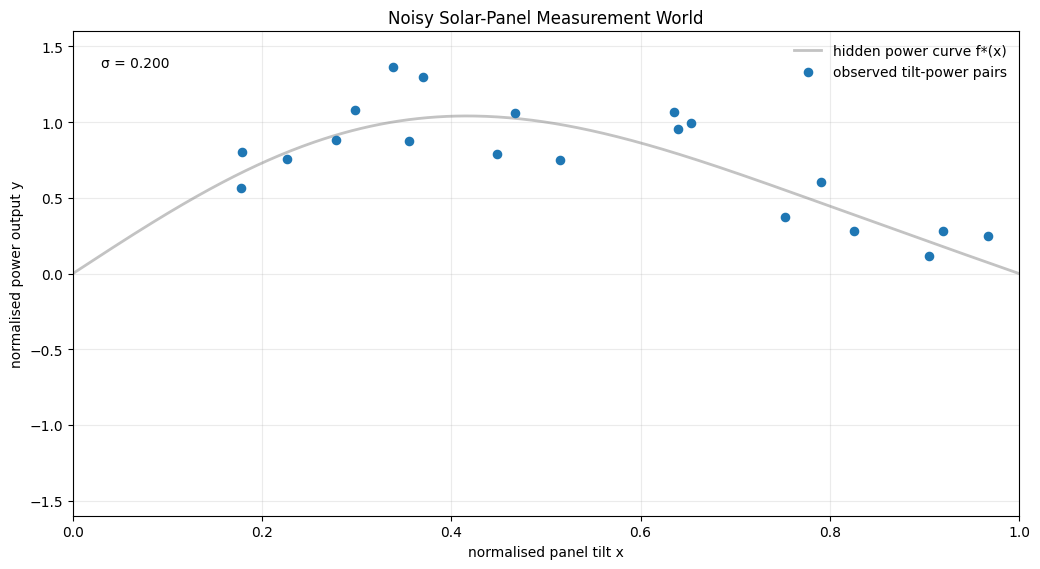

In [3]:
# Visualise the fixed evidence.
fig = plots.plot_measurement_world(x_observed, y_observed, noise_std=noise_std)
show_fig(fig)

# residual_fig = plots.plot_residual_histogram(x_observed, y_observed)
# show_fig(residual_fig)


<br>

## 3. Define $\mathcal{H}$: Candidate Explanations

Features and parameters define the functions the learner can build.


Notebook 01 asked what evidence was available. A hypothesis space asks what forms of explanation are allowed before fitting.

In the solar-panel example, a hypothesis is one rule from panel tilt to power output. A line allows constant change. A quadratic allows one smooth bend. A cubic adds an inflection. These are modelling choices, not conclusions from the data.

Use the building-block view:

- the feature map supplies shapes such as $1$, $x$, $x^2$, and $x^3$;
- the parameter vector $\theta$ mixes those shapes;
- one $\theta$ builds one curve;
- $\mathcal{H}$ is every curve available from the allowed blocks.

For fixed-feature regression,

$$
h_\theta(x)=\theta^\top\phi(x).
$$

For all observed panel tilts, stack features into $\Phi$. Training predictions are

$$
\hat{y}=\Phi\theta.
$$

The parameter vector is one choice inside the space. The hypothesis space is the full set:

$$
\mathcal{H}=\{h_\theta:x\mapsto\theta^\top\phi(x)\mid\theta\in\Theta\}.
$$

### Parameter space versus hypothesis space

The **parameter space** $\Theta$ is the set of allowed settings for the knobs. For a degree-$d$ polynomial, those knobs are the coefficients on $1, x, x^2, \ldots, x^d$, so $\Theta$ is usually $\mathbb{R}^{d+1}$.

The **hypothesis space** $\mathcal{H}$ is not the knobs themselves. It is the set of functions produced when those knobs are used inside a particular model form. With polynomial features, sweeping through all allowed coefficient vectors produces all polynomial curves up to degree $d$.

That distinction matters because the same-looking parameter space can create very different hypothesis spaces. Two real-valued parameters might define a straight line $\theta_0 + \theta_1x$, a scaled sine wave $\theta_0\sin(\theta_1x)$, or a threshold rule. The parameter vector has the same length, but the available functions have very different shapes.

It also matters in the other direction: the same hypothesis space can be described with different coordinates. Later in this notebook, monomial and Chebyshev polynomial features span the same degree-$d$ polynomial function space, even though their parameter values and numerical behaviour differ.

So use this rule of thumb:

- changing $\theta$ usually changes which function is selected inside a fixed $\mathcal{H}$;
- changing the feature map, model form, degree, constraints, or allowable parameter set changes $\mathcal{H}$;
- changing coordinates may change how easy the search is without changing the functions available.

Choosing $\mathcal{H}$ sets an inductive bias: straight, smooth, low-degree, periodic, saturating, monotone, local, or something else.

First diagnostic: before fitting, ask what can be built and what is impossible no matter how $\theta$ is tuned.


### Formulation checkpoint: choose the explanation menu
Before inspecting polynomial features, decide what kind of explanation you are willing to allow.

- Should the rule be almost straight, gently curved, or very flexible?
- Which behaviours should be impossible even if they reduce training error?
- Am I only changing coefficient values, or am I changing the kind of functions those coefficients can make?
- What would make the model class inappropriate for the solar-panel story?

This is a hypothesis-space decision. It is made before any optimizer selects a particular function.


<br>

## 4. Feature Columns Define What Can Be Built

Feature columns are reusable shapes that parameters mix into curves.


The next step makes the building-block view concrete. Begin with polynomial feature columns:

$$
\phi_d(x) = [1, x, x^2, \ldots, x^d].
$$

This defines the degree-$d$ polynomial hypothesis space:

$$
\mathcal{H}_d = \{x \mapsto \theta^\top\phi_d(x) \mid \theta \in \mathbb{R}^{d+1}\}.
$$

Expanded out, the dot product is just a weighted sum of the available building blocks:

$$
\theta^\top\phi_d(x)
= \theta_0\cdot 1 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d.
$$

For example, with degree 3,

$$
h_\theta(x)=\theta_0 + \theta_1x + \theta_2x^2 + \theta_3x^3.
$$

The feature map chooses the building blocks. The parameter vector chooses the recipe. If $\theta_2=0$, the quadratic block is present but unused. If the feature map does not contain a block capable of a sharp local change, no parameter setting can create that behaviour.

Each column is a shape over the tilt-setting range. Each entry of $\theta$ says how strongly to mix one column into the final curve. If a useful power-output shape cannot be built from these columns, fitting can only choose the closest explanation this representation makes available.

This is the second hypothesis-space diagnostic: inspect the feature columns as shapes, not just as algebra. The word *basis* is used when the columns are linearly independent and span the function class being discussed. More generally, people may call the collection a feature dictionary.


### 4.1 Before running: read features as shapes

The next cells first print a few feature rows, then show two small families of candidate curves: several straight lines and several parabolas. Read the curves as possible power-output rules before any fitting occurs. The same section then shows the feature columns and a few explicit weighted combinations.

The example combinations are:

$$
h_1(x)=0.70-1.10x,
$$

$$
h_2(x)=-0.35+2.40x-2.00x^2,
$$

$$
h_3(x)=4.00x-12.00x^2+8.00x^3.
$$

Before running, predict which shapes are available when the degree is 0, 1, 2, 3, and 4. Which shapes are building blocks, and which shapes are complete curves built by mixing those blocks?


### Implementation reveal: features are the model's vocabulary
A polynomial model is not magic notation. The helper builds a matrix $\Phi$ whose columns are reusable shapes. A parameter vector $\theta$ mixes those columns into one candidate function.


In [4]:
# Open the box: polynomial_features builds the design matrix Phi.
toy_x = np.array([0.0, 0.5, 1.0])
toy_degree = 3
toy_theta = np.array([0.25, -0.50, 0.75, -0.20])
toy_Phi = models.polynomial_features(toy_x, degree=toy_degree)
toy_prediction = toy_Phi @ toy_theta

toy_rows = []
for x_value, row, prediction in zip(toy_x, toy_Phi, toy_prediction):
    toy_rows.append(
        {"x": x_value, **{f"x^{power}": row[power] for power in range(toy_degree + 1)}, "Phi@theta": prediction}
    )

print_rows(toy_rows, digits=4, title="Three inputs turned into feature columns")
print_rows(
    [{"feature": f"x^{power}", "theta": value} for power, value in enumerate(toy_theta)],
    digits=4,
    title="The parameter vector mixes those columns",
)


Three inputs turned into feature columns
01. x=0, x^0=1.0000, x^1=0, x^2=0, x^3=0, Phi@theta=0.2500
02. x=0.5000, x^0=1.0000, x^1=0.5000, x^2=0.2500, x^3=0.1250, Phi@theta=0.1625
03. x=1.0000, x^0=1.0000, x^1=1.0000, x^2=1.0000, x^3=1.0000, Phi@theta=0.3000
The parameter vector mixes those columns
01. feature=x^0, theta=0.2500
02. feature=x^1, theta=-0.5000
03. feature=x^2, theta=0.7500
04. feature=x^3, theta=-0.2000


First rows of Phi, with one chosen theta
01. x=0.1774, x^0=1.0000, x^1=0.1774, x^2=0.0315, x^3=0.0056, x^4=0.0010, Phi@theta=0.1805
02. x=0.1789, x^0=1.0000, x^1=0.1789, x^2=0.0320, x^3=0.0057, x^4=0.0010, Phi@theta=0.1802
03. x=0.2263, x^0=1.0000, x^1=0.2263, x^2=0.0512, x^3=0.0116, x^4=0.0026, Phi@theta=0.1736
04. x=0.2779, x^0=1.0000, x^1=0.2779, x^2=0.0772, x^3=0.0215, x^4=0.0060, Phi@theta=0.1712
05. x=0.2983, x^0=1.0000, x^1=0.2983, x^2=0.0890, x^3=0.0265, x^4=0.0079, Phi@theta=0.1715
Mixing weights theta
01. feature_column=x^0, theta=0.2500
02. feature_column=x^1, theta=-0.6000
03. feature_column=x^2, theta=1.2000
04. feature_column=x^3, theta=0
05. feature_column=x^4, theta=-0.8000


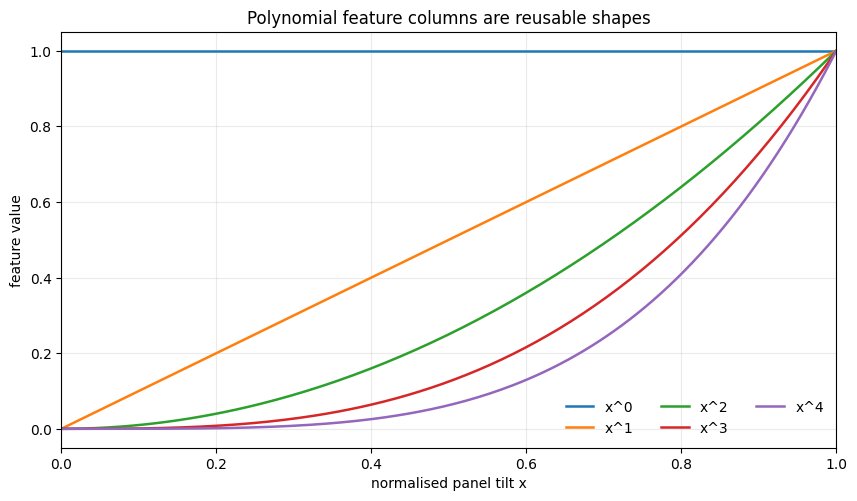

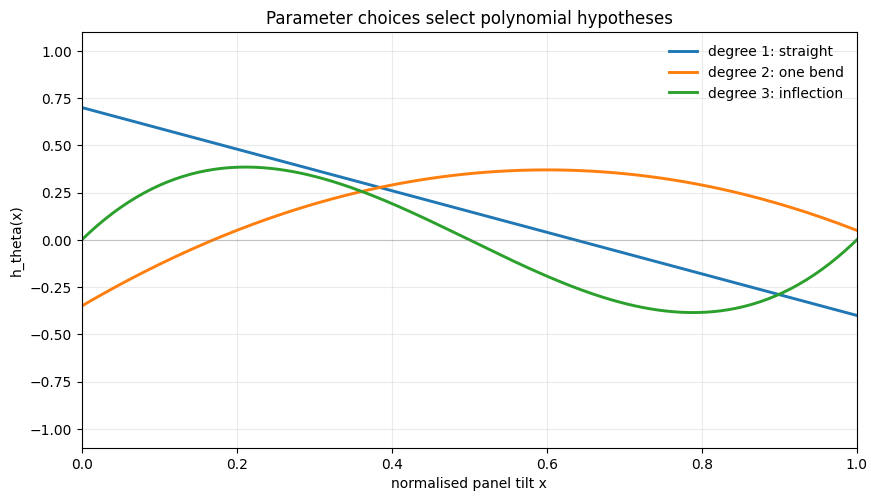

In [5]:
# Inspect Phi, choose theta, and compute Phi @ theta.
degree_preview = 4
x_preview = x_observed[:5]
Phi_preview = models.polynomial_features(x_preview, degree=degree_preview)
theta_preview = np.array([0.25, -0.60, 1.20, 0.00, -0.80])
preview_predictions = Phi_preview @ theta_preview

feature_rows = []
for x_value, row, prediction in zip(x_preview, Phi_preview, preview_predictions):
    feature_rows.append(
        {"x": x_value, **{f"x^{power}": row[power] for power in range(degree_preview + 1)}, "Phi@theta": prediction}
    )

print_rows(feature_rows, digits=4, title="First rows of Phi, with one chosen theta")
print_rows(
    [{"feature_column": f"x^{power}", "theta": theta_value} for power, theta_value in enumerate(theta_preview)],
    digits=4,
    title="Mixing weights theta",
)

x_shape_grid = data.make_test_grid(n_points=200)

line_examples = [
    ("gentle rise", np.array([-0.45, 0.90])),
    ("flat", np.array([0.15, 0.00])),
    ("steep fall", np.array([0.85, -1.45])),
]
parabola_examples = [
    ("opens down", np.array([-0.20, 2.20, -2.10])),
    ("opens up", np.array([0.55, -2.00, 2.00])),
    ("off-centre bend", np.array([0.20, 1.00, -1.60])),
]

Phi_shape_grid = models.polynomial_features(x_shape_grid, degree=degree_preview)
fig, ax = plt.subplots(figsize=(10.0, 5.4))
for power in range(degree_preview + 1):
    ax.plot(x_shape_grid, Phi_shape_grid[:, power], linewidth=1.8, label=f"x^{power}")
ax.set_title("Polynomial feature columns are reusable shapes")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("feature value")
ax.set_xlim(0.0, 1.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=3)
show_fig(fig)

example_hypotheses = [
    ("degree 1: straight", np.array([0.70, -1.10])),
    ("degree 2: one bend", np.array([-0.35, 2.40, -2.00])),
    ("degree 3: inflection", np.array([0.00, 4.00, -12.00, 8.00])),
]

fig, ax = plt.subplots(figsize=(10.0, 5.4))
for label, theta in example_hypotheses:
    Phi_curve = models.polynomial_features(x_shape_grid, degree=len(theta) - 1)
    ax.plot(x_shape_grid, Phi_curve @ theta, linewidth=2.1, label=label)
ax.axhline(0.0, color="#777777", linewidth=0.8, alpha=0.35)
ax.set_title("Parameter choices select polynomial hypotheses")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("h_theta(x)")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


### 4.2 After running: identify the available shapes

Inspect the feature columns and the example curves.

- Which columns create vertical shift, slope, curvature, and more complex bending?
- Which behaviours are impossible if a column is missing?
- Where might these columns behave badly outside observed support?

A feature map is a hypothesis-space design choice. It decides what kinds of functions can be built before fitting begins.


The first plot shows whole families of possible curves. No data have been fitted yet; the curves are just examples of what different parameter choices can build from the same kind of blocks.

The second plot shows the raw feature columns. The third plot shows selected hypotheses built by mixing those columns with the example weights listed above. With only $1$ and $x$, every selected function is a straight line. Adding $x^2$ makes one bend available. Adding $x^3$ makes an inflection pattern available.

This is the hypothesis-space decision in miniature. More columns can make useful behaviours available, but they also add behaviours that may track measurement noise or behave strangely where the data provide weak support. Notebook 01 showed where support is weak; here we see how $\mathcal{H}$ determines what can happen in those unsupported regions.

> **Discuss.** Before fitting, which power-output behaviours seem easy to build from these columns, and where might this representation struggle to explain the measured pattern?


<br>

## 5. Select One Candidate by Hand

Choosing one parameter vector selects one function from the space.


After defining the space, select one candidate from it. Before letting an optimiser choose the parameters, choose the mixing weights yourself and rerun the cell.

### Before running: distinguish $\theta$ from $\mathcal{H}$

Changing `manual_theta` changes one selected function inside the current hypothesis space. Changing `manual_degree` changes the feature map and therefore the hypothesis space itself.

Use this table as you experiment:

| Edit | What changed? | Which part of the frame changed? |
|---|---|---|
| Change one coefficient | | |
| Add a coefficient by increasing degree | | |
| Change the dataset settings | | |


Manual parameter choice
01. feature=x^0, theta=0
02. feature=x^1, theta=-1.0000
03. feature=x^2, theta=0
04. feature=x^3, theta=2.0000
What this theta produces on the observed measurements
01. quantity=Phi shape on D, value=(20, 4)
02. quantity=theta shape, value=(4,)
03. quantity=train MSE for this theta, value=1.0163


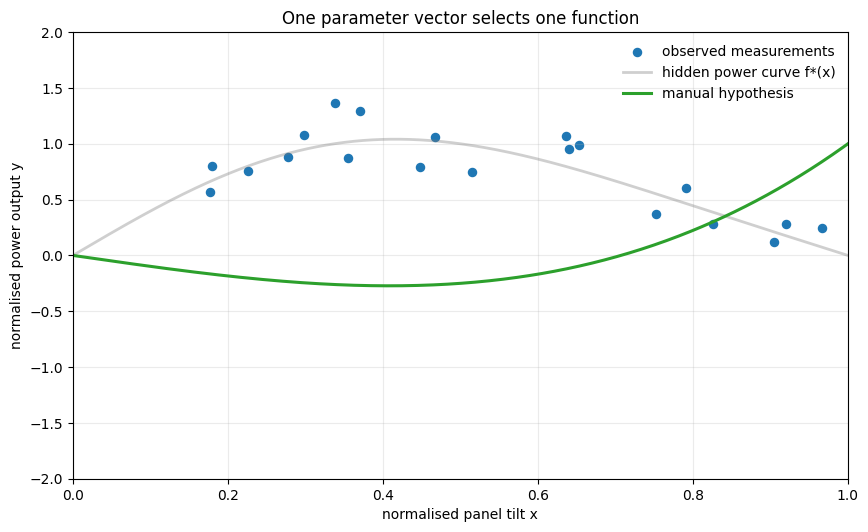

In [6]:
# Manual parameter exploration. Edit theta and rerun.
manual_degree = 3
manual_theta = np.array([0.0, -1.0, 0.0, 2.0])  # theta_0, theta_1, ..., theta_degree

if len(manual_theta) != manual_degree + 1:
    raise ValueError("manual_theta must have manual_degree + 1 entries")

x_grid = data.make_test_grid(n_points=500)
Phi_grid_manual = models.polynomial_features(x_grid, degree=manual_degree)
manual_curve = Phi_grid_manual @ manual_theta
Phi_observed_manual = models.polynomial_features(x_observed, degree=manual_degree)
manual_train_predictions = Phi_observed_manual @ manual_theta

print_rows(
    [{"feature": f"x^{power}", "theta": theta_value} for power, theta_value in enumerate(manual_theta)],
    title="Manual parameter choice",
)
print_rows(
    [
        {"quantity": "Phi shape on D", "value": str(Phi_observed_manual.shape)},
        {"quantity": "theta shape", "value": str(manual_theta.shape)},
        {"quantity": "train MSE for this theta", "value": metrics.mse(y_observed, manual_train_predictions)},
    ],
    title="What this theta produces on the observed measurements",
)

fig, ax = plt.subplots(figsize=(10.0, 5.8))
ax.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed measurements")
ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
ax.plot(x_grid, manual_curve, color="#2ca02c", linewidth=2.2, label="manual hypothesis")
ax.set_title("One parameter vector selects one function")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-2.0, 2.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


<br>

## 6. Separate $\mathcal{H}$ From the Selected $s$

The hypothesis space is the menu; the selected solution is one item from it.


### Anchor distinction

The hypothesis space is the menu of possible functions. The parameter space is the coordinate system used to move around that menu. A parameter vector is one location in that coordinate system, and that location maps to one candidate function. The optimiser will later automate the search, but it cannot select a function that the model form does not make available.

The manual controls above make the selection step visible. The feature map defines the available shapes, and one parameter vector $\theta$ selects one function $h_\theta$ from that space. In the workshop frame, $\mathcal{H}$ is the candidate set; $s$ is the selected solution.

In $\mathcal{H} + \mathcal{D} + \mathcal{O} \rightarrow s$ language, changing `manual_theta` changed the selected solution $s$ while the evidence $\mathcal{D}$ and hypothesis space $\mathcal{H}$ stayed fixed. Changing `manual_degree` changed $\mathcal{H}$ because it changed which polynomial functions were representable.

This is why parameter count alone is a poor description of what the learner can do. A two-parameter line and a two-parameter sine curve both have two knobs, but they encode different assumptions about the world. A different basis for the same polynomial space may change the coefficients without changing the set of curves. The substantive question is not only "how many parameters are there?" but "what functions do these parameters generate?"

An optimiser will do the same kind of selection automatically: it searches the parameter space $\Theta$, chooses a value $\hat{\theta}$ according to an objective, and thereby selects the fitted hypothesis $h_{\hat{\theta}}\in\mathcal{H}$.

The important separation is:

- choosing $\phi$ and allowable $\Theta$ defines what can be represented;
- choosing a fitting objective defines which representable function is selected from the observed measurements.

The next section keeps $\mathcal{D}$ and the least-squares selector steady, then changes the menu itself by increasing the polynomial degree.


In [7]:
# Fit one polynomial after seeing how manual parameters behave.
degree_single = 3
coeffs_single = models.fit_polynomial_mle(x_observed, y_observed, degree=degree_single)
train_pred_single = models.predict_polynomial(x_observed, coeffs_single)

print_rows(
    [{"feature": f"x^{i}", "selected_theta": coeff} for i, coeff in enumerate(coeffs_single)],
    title=f"Selected theta values for degree {degree_single}",
)
print_rows(
    [{"degree": degree_single, "train_mse": metrics.mse(y_observed, train_pred_single), "coef_norm": metrics.coefficient_norm(coeffs_single)}],
    title="Fit summary",
)


Selected theta values for degree 3
01. feature=x^0, selected_theta=-0.4023
02. feature=x^1, selected_theta=8.3093
03. feature=x^2, selected_theta=-13.8753
04. feature=x^3, selected_theta=6.0777
Fit summary
01. degree=3, train_mse=0.0301, coef_norm=17.2820


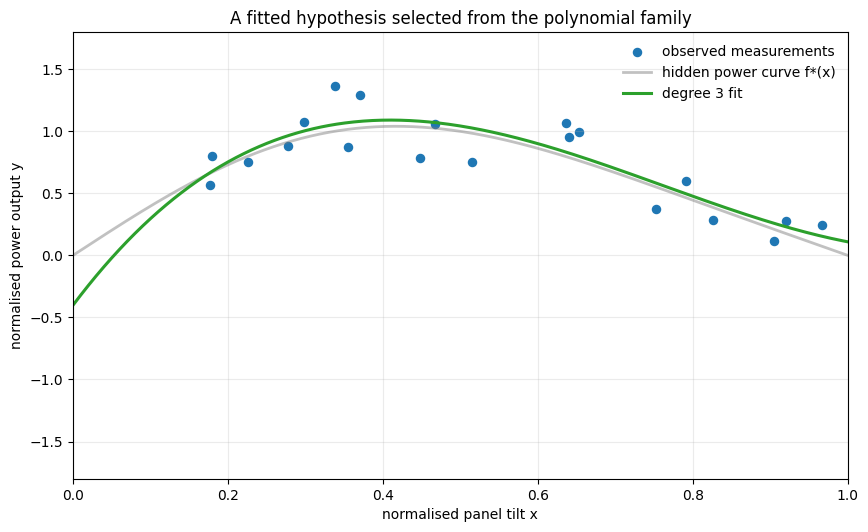

In [8]:
# Plot the fitted hypothesis against the data and the hidden function.
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)
y_grid_single = models.predict_polynomial(x_grid, coeffs_single)

fig, ax = plt.subplots(figsize=(10.0, 5.8))
ax.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed measurements")
ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.45, linewidth=2.0, label="hidden power curve f*(x)")
ax.plot(x_grid, y_grid_single, color="#2ca02c", linewidth=2.2, label=f"degree {degree_single} fit")
ax.set_title("A fitted hypothesis selected from the polynomial family")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("normalised power output y")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.8, 1.8)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
show_fig(fig)


<br>

## 7. Change $\mathcal{H}$ While $\mathcal{D}$ Stays Fixed

Changing polynomial degree changes what behaviours are available.


Now keep $\mathcal{D}$ fixed and change only the polynomial degree. This isolates one hypothesis-space lever: the size of the polynomial feature dictionary. The question is no longer "which $\theta$ did we pick?" but "what did this version of $\mathcal{H}$ make possible?"

The degree controls the size of the feature map and gives a family of hypothesis spaces:

$$
\mathcal{H}_d = \{x \mapsto \theta^\top \phi_d(x) \mid \theta \in \mathbb{R}^{d+1}\}.
$$

Polynomial spaces are nested. A degree-3 polynomial is available inside a degree-9 space by setting the parameters on $x^4, \ldots, x^9$ to zero. Increasing $d$ keeps earlier explanations and adds new ones.

### Before running: predict the model-complexity pattern

The next cells keep $\mathcal{D}$ and the least-squares selector fixed while changing polynomial degree. That means the active lever is $\mathcal{H}$.

Fill this table before running:

| Degree | Expected training error | Expected behaviour away from data | Reason |
|---:|---|---|---|
| 0 | | | |
| 1 | | | |
| 3 | | | |
| 9 | | | |

The next cells compare training error, an oracle grid error for this simulation, parameter norm, conditioning, and fitted prediction range. Read these as diagnostics of what the chosen hypothesis space made possible, especially in the gaps and weakly supported regions identified in Notebook 01.


### Group experiment: choose complexity before seeing the score
Assign each group one degree from the next comparison. Before running the cell, each group should predict:

- what their degree can represent well;
- where it should fail;
- whether lower training error would be enough to trust it.

After the plots, compare predictions. The goal is not to pick the most flexible space; it is to explain what each space makes possible and risky.


In [9]:
# Compare several hypothesis spaces on exactly the same observations.
degrees = (0, 1, 3, 9)
x_grid = data.make_test_grid(n_points=500)
y_grid_true = data.true_function(x_grid)

hypothesis_rows = []
hypothesis_fits = {}

for degree in degrees:
    Phi = models.polynomial_features(x_observed, degree=degree)
    coeffs = models.fit_polynomial_mle(x_observed, y_observed, degree=degree)
    train_pred = models.predict_polynomial(x_observed, coeffs)
    grid_pred = models.predict_polynomial(x_grid, coeffs)
    hypothesis_fits[degree] = {"coeffs": coeffs, "grid_pred": grid_pred}
    hypothesis_rows.append(
        {
            "degree": degree,
            "n_features": degree + 1,
            "train_mse": metrics.mse(y_observed, train_pred),
            "oracle_grid_mse": metrics.mse(y_grid_true, grid_pred),
            "coef_norm_warning": metrics.coefficient_norm(coeffs),
            "condition_number": np.linalg.cond(Phi),
            "pred_min": np.min(grid_pred),
            "pred_max": np.max(grid_pred),
        }
    )

print_rows(hypothesis_rows, digits=4, title="Same data, different polynomial spaces")

Same data, different polynomial spaces
01. degree=0, n_features=1, train_mse=0.1205, oracle_grid_mse=0.1214, coef_norm_warning=0.7570, condition_number=1.0000, pred_min=0.7570, pred_max=0.7570
02. degree=1, n_features=2, train_mse=0.0709, oracle_grid_mse=0.1530, coef_norm_warning=1.5100, condition_number=5.1396, pred_min=0.3507, pred_max=1.2286
03. degree=3, n_features=4, train_mse=0.0301, oracle_grid_mse=0.0083, coef_norm_warning=17.2820, condition_number=236.1409, pred_min=-0.4023, pred_max=1.0909
04. degree=9, n_features=10, train_mse=0.0171, oracle_grid_mse=181.4153, coef_norm_warning=1.68e+06, condition_number=5.96e+07, pred_min=-93.5510, pred_max=1.5080


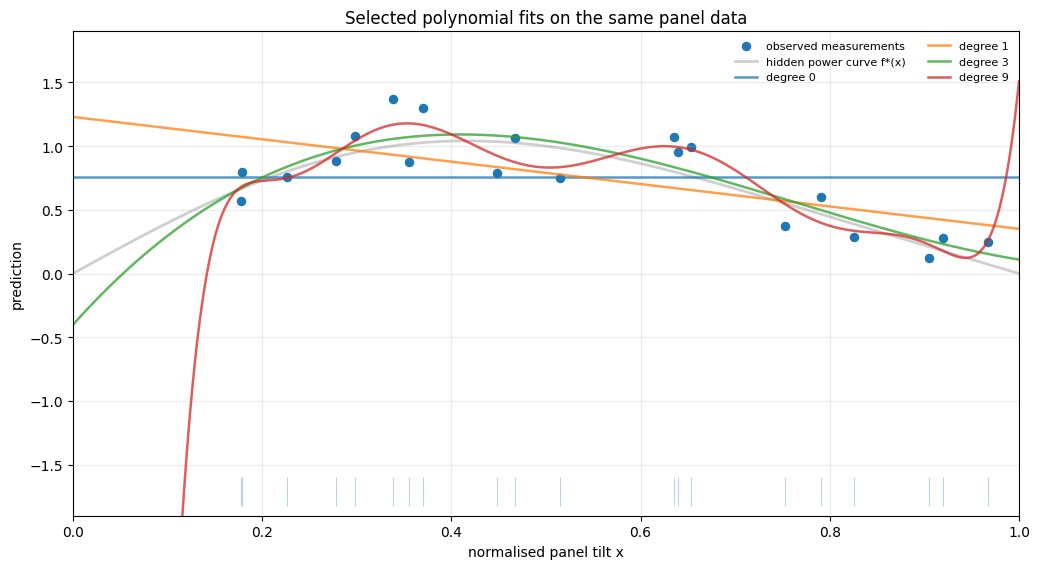

In [10]:
# Plot the selected functions after inspecting the summaries.
colors = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.scatter(x_observed, y_observed, s=34, color="#1f77b4", label="observed measurements")
ax.plot(x_grid, y_grid_true, color="#777777", alpha=0.35, linewidth=2.0, label="hidden power curve f*(x)")
ax.vlines(x_observed, 0.02, 0.08, transform=ax.get_xaxis_transform(), color="#1f77b4", alpha=0.30, linewidth=0.8)
for idx, degree in enumerate(degrees):
    ax.plot(
        x_grid,
        hypothesis_fits[degree]["grid_pred"],
        color=colors(idx),
        linewidth=1.8,
        label=f"degree {degree}",
        alpha=0.75,
    )
ax.set_title("Selected polynomial fits on the same panel data")
ax.set_xlabel("normalised panel tilt x")
ax.set_ylabel("prediction")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(-1.9, 1.9)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncol=2)
fig.tight_layout()
show_fig(fig)


### 7.1 After running: diagnose the hypothesis-space lever

Read the comparison in terms of what was possible.

- If the degree is too low, the required shape is not available.
- If the degree is high, training rows can be matched more closely.
- If the degree is too high relative to the data, unsupported behaviours can appear between or beyond observations.

Increasing $\mathcal{H}$ increases what can be represented. It does not guarantee that the selected function is more defensible.

Use the table, clipped plot, and bottom ticks together. The ticks mark measured panel tilts; large curve movement between ticks is behaviour that the data weakly constrain. The table columns `coef_norm_warning`, `condition_number`, `pred_min`, and `pred_max` are warning signs that the selected curve may be using fragile directions in the hypothesis space. The `oracle_grid_mse` column is available only because this is a simulation. In real work, use held-out data, residual checks, domain knowledge, sensitivity analysis, and the deployment region.

> **Discuss.** Which curve would you defend as a scientific explanation, what part of the table or plot makes you uneasy, and why?


<br>

## 9. Separate Function Space From Coordinates

The same function space can have easier or harder numerical coordinates.


### Optional advanced checkpoint: functions versus coordinates

Skip this on a first pass if the main distinction is already clear. Separate two ideas:

- the **function space**: the curves that can be represented;
- the **coordinate system**: how we describe and search that space numerically.

Changing coordinates need not change $\mathcal{H}$. Degree-$d$ polynomials can use raw monomials $1,x,x^2,\ldots,x^d$ or shifted Chebyshev polynomials on $[0,1]$.

Let $z=2x-1$. The first shifted Chebyshev columns are

$$
T_0(z)=1,
$$

$$
T_1(z)=z=2x-1,
$$

$$
T_2(z)=2z^2-1=8x^2-8x+1,
$$

$$
T_3(z)=4z^3-3z=32x^3-48x^2+18x-1.
$$

Each is a polynomial in $x$, so Chebyshev combinations up to degree $d$ lie inside the ordinary degree-$d$ polynomial space:

$$
\sum_{k=0}^d a_k T_k(2x-1) \in \operatorname{span}\{1,x,x^2,\ldots,x^d\}.
$$

The reverse is also true because the transformation is triangular with non-zero leading terms. For example,

$$
x=\frac{T_1(2x-1)+1}{2},
$$

$$
x^2=\frac{T_2(2x-1)+4T_1(2x-1)+3}{8}.
$$

So the two bases span the same function space:

$$
\operatorname{span}\{1,x,x^2,\ldots,x^d\}
=
\operatorname{span}\{T_0(2x-1),\ldots,T_d(2x-1)\}.
$$

They can still behave differently numerically. Same $\mathcal{H}$, different coefficient sizes, condition numbers, and sensitivity to small data changes.

The next cell compares the columns and condition numbers. The handoff is: Notebook 02 asks what functions are possible; Notebook 03 asks what rule selects one.


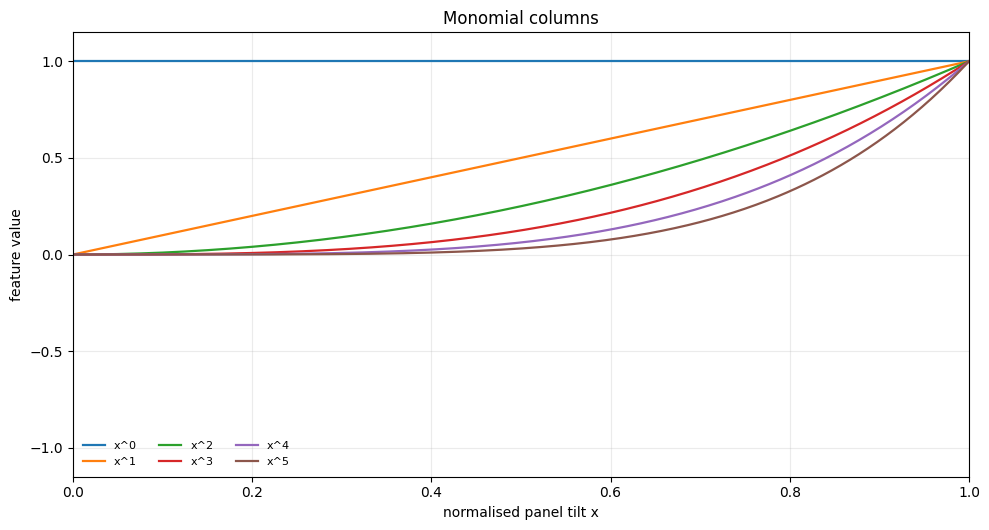

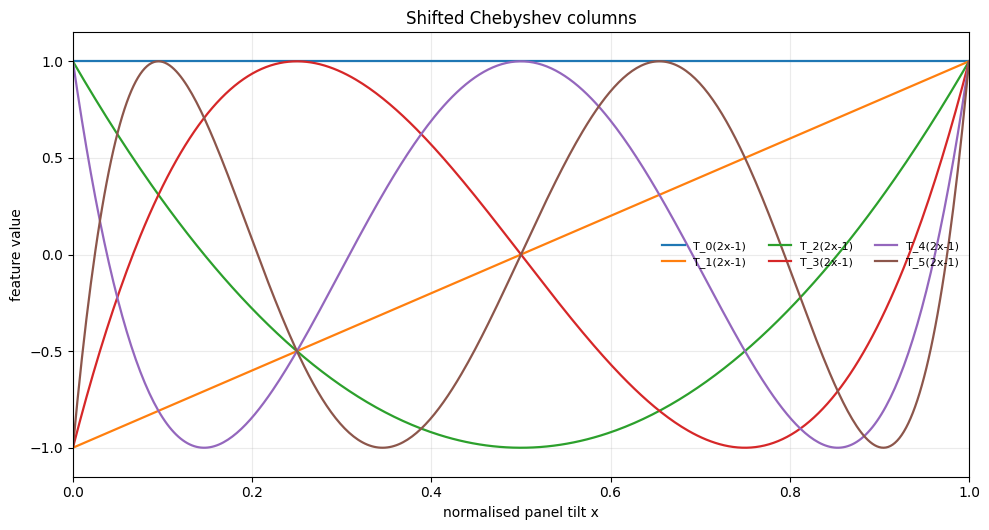

Same polynomial space, different conditioning
01. feature_coordinates=monomial powers, condition_number=2.98e+13
02. feature_coordinates=shifted Chebyshev, condition_number=7.13e+05


In [12]:
# Compare two coordinate systems for the same degree-limited polynomial space.
conditioning_degree = 15
visual_degree = 5

x_grid = data.make_test_grid(n_points=400)
x_shifted_grid = 2.0 * x_grid - 1.0
Phi_monomial_visual = models.polynomial_features(x_grid, degree=visual_degree)
Phi_chebyshev_visual = np.polynomial.chebyshev.chebvander(x_shifted_grid, deg=visual_degree)

coordinate_views = [
    ("Monomial columns", Phi_monomial_visual, lambda degree: f"x^{degree}"),
    ("Shifted Chebyshev columns", Phi_chebyshev_visual, lambda degree: f"T_{degree}(2x-1)"),
]

for title, feature_matrix, labeler in coordinate_views:
    fig, ax = plt.subplots(figsize=(10.0, 5.4))
    for degree in range(visual_degree + 1):
        ax.plot(x_grid, feature_matrix[:, degree], linewidth=1.6, label=labeler(degree))
    ax.set_title(title)
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("feature value")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.15, 1.15)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=3)
    fig.tight_layout()
    show_fig(fig)

x_shifted = 2.0 * x_observed - 1.0
Phi_monomial = models.polynomial_features(x_observed, degree=conditioning_degree)
Phi_chebyshev = np.polynomial.chebyshev.chebvander(x_shifted, deg=conditioning_degree)

print_rows(
    [
        {"feature_coordinates": "monomial powers", "condition_number": np.linalg.cond(Phi_monomial)},
        {"feature_coordinates": "shifted Chebyshev", "condition_number": np.linalg.cond(Phi_chebyshev)},
    ],
    digits=4,
    title="Same polynomial space, different conditioning",
)


<br>

## 10. Summary: What $\mathcal{H}$ Adds and What It Cannot Decide

Hypothesis space controls possibility, not final trust.


1. **Feature columns define available shapes.** A low-degree space may miss the needed shape entirely.
2. **Parameters are coordinates, not the model family.** The parameter space tells us which knob settings are allowed; the hypothesis space tells us what functions those settings can generate.
3. **Approximation error is a hypothesis-space limit.** Even the best function inside $\mathcal{H}$ may be far from the hidden response.
4. **Larger spaces trade underfitting for fragility.** High degree can lower training error while making gaps and edges hard to defend.
5. **Finite data may not identify one explanation.** Different functions can agree on $\mathcal{D}$ and disagree between rows.
6. **Selection pressure comes next.** If several hypotheses fit well, $\mathcal{D}$ has not chosen among them. $\mathcal{O}$ does that.
7. **Coordinates are not functions.** Monomial and Chebyshev coordinates can span the same polynomial space but behave very differently numerically.

`oracle_grid_mse` is available only because this is a simulation. In real work, the substitutes are held-out data, residual checks, domain checks, sensitivity analysis, and judgement.

> **Discuss.** Which power-output curve would you trust outside measured panel tilts, and what assumption makes that trust reasonable?


<br>

## 11. Bridge to Notebook 03

After naming possible functions, we need a rule that selects one.


Notebook 01 asked what evidence was available: what was recorded, where it was recorded, how noisy it was, and where it left gaps. Notebook 02 asked what explanations were possible: what shapes were available, which functions could be selected, and which behaviours remained underdetermined by that same finite evidence.

That still leaves one ingredient unresolved. A hypothesis space contains candidates; it does not choose among them. Notebook 03 keeps $\mathcal{D}$ and $\mathcal{H}$ visible, then studies $\mathcal{O}$: the losses, penalties, and selection rules that turn available candidates into one selected solution $s$.


<br>

## 12. References

These references support the hypothesis-space, polynomial-feature, and conditioning ideas used here.


- Bishop, C. M. (2006). [*Pattern Recognition and Machine Learning*](https://link.springer.com/book/9780387310732). Polynomial curve fitting, linear basis-function models, model complexity, and overfitting.
- Trefethen, L. N. (2019). [*Approximation Theory and Approximation Practice, Extended Edition*](https://epubs.siam.org/doi/10.1137/1.9781611975949). Polynomial approximation, Chebyshev approximation, and Runge-type instability.
- Trefethen, L. N., & Bau, D., III. (1997). [*Numerical Linear Algebra*](https://epubs.siam.org/doi/10.1137/1.9780898719574). Rank, null spaces, singular values, least squares, and conditioning.
